# Trabajo Práctico 2 — Tecnología Digital VI

**Integrantes:** Facundo Arechaga, Franco Bergman

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")

### 1. Introducción al problema y Análisis Exploratorio

- i) El conjunto de datos utilizado en este trabajo práctico contiene información sobre distintas canciones obtenida a partir de métricas acústicas de Spotify. Cada fila representa una canción y cada columna contiene distintas características musicales que describen aspectos como su energía, ritmo, popularidad o nivel de instrumentalidad.

El objetivo del problema es utilizar estas características para predecir a qué género musical pertenece cada canción.

Hay varias variables:

- **Id:** Identificador único de cada canción.

- **popularity:** Nivel de popularidad de la canción.

- **duration_ms:** Duración de la canción medida en milisegundos.

- **explicit:** Indica si la canción contiene contenido explícito.

- **danceability:** Representa qué tan adecuada es una canción para bailar, teniendo en cuenta elementos como el tempo, la estabilidad del ritmo y la regularidad general.

- **energy:** Mide la intensidad y actividad percibida de una canción. Valores altos suelen corresponder a canciones más rápidas, fuertes o intensas.

- **key:** Representa la tonalidad musical principal de la canción.

- **loudness:** Volumen general de la canción, medido en decibeles.

- **mode:** Indica si la canción está principalmente en modo mayor o menor.

- **speechiness:** Mide la presencia de palabras habladas dentro de la canción.

- **acousticness:** Estima qué tan acústica es una canción. Valores altos indican una mayor presencia de instrumentos o sonidos acústicos.

- **instrumentalness:** Indica la probabilidad de que una canción sea principalmente instrumental y tenga poca o ninguna presencia vocal.

- **liveness:** Mide la probabilidad de que la grabación haya sido realizada en vivo.

- **valence:** Representa el carácter emocional de la canción. Valores altos suelen asociarse con canciones más positivas o alegres.

- **tempo:** Indica la velocidad de la canción, generalmente medida en beats por minuto.

- **time_signature:** Indica el compás de la canción, es decir, cuántos tiempos o pulsos hay en cada compás.

La variable objetivo es **Expected**, que indica el género musical al que pertenece cada canción. En este caso, se trata de un problema de **clasificación multiclase**, ya que existen varios géneros posibles: jazz, electronic, hip-hop, acoustic, rock y classical.

El problema consiste en desarrollar un modelo de Machine Learning capaz de identificar correctamente el género de una canción utilizando únicamente sus características acústicas.

Además, buscamos analizar qué variables permiten diferenciar mejor los distintos géneros y comparar distintos modelos de clasificación.

Desde el punto de vista de negocio, este tipo de modelo podría ser útil para una plataforma como Spotify para clasificar automáticamente canciones nuevas, organizar catálogos y mejorar sistemas de recomendación.

En este contexto, no solo interesa acertar exactamente el género principal, sino también que el género correcto aparezca entre las principales predicciones del modelo. Por eso, además de utilizar **F1-Macro**, también se analizará la métrica **MAP@3**, que evalúa si el género correcto aparece dentro de las tres predicciones principales del modelo.

In [2]:
df.head() # Muestra las primeras 5 filas del DataFrame

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected,Id
0,0,143733,False,0.439,0.196,0,-16.093,1,0.0601,0.88000,0.0000,0.0513,0.525,129.581,4,jazz,4271
1,0,261562,False,0.627,0.876,11,-4.391,0,0.0324,0.01590,0.0000,0.0665,0.418,111.950,4,electronic,2078
2,63,190131,False,0.767,0.869,2,-3.381,0,0.0908,0.14000,0.0000,0.2210,0.751,98.208,4,hip-hop,4921
3,48,201440,False,0.374,0.183,9,-13.225,1,0.0281,0.89700,0.0387,0.1090,0.134,82.042,4,acoustic,4206
4,0,168552,True,0.423,0.721,0,-8.070,1,0.1650,0.00792,0.0000,0.3800,0.382,161.926,4,rock,2423


In [3]:
df.shape # Muestra el número de filas y columnas del DataFrame

(4200, 17)

In [4]:
df.info() # Muestra información sobre el DataFrame, incluyendo el tipo de datos de cada columna y la cantidad de valores no nulos

<class 'pandas.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        4200 non-null   int64  
 1   duration_ms       4200 non-null   int64  
 2   explicit          4200 non-null   bool   
 3   danceability      4200 non-null   float64
 4   energy            4200 non-null   float64
 5   key               4200 non-null   int64  
 6   loudness          4200 non-null   float64
 7   mode              4200 non-null   int64  
 8   speechiness       4200 non-null   float64
 9   acousticness      4200 non-null   float64
 10  instrumentalness  4200 non-null   float64
 11  liveness          4200 non-null   float64
 12  valence           4200 non-null   float64
 13  tempo             4200 non-null   float64
 14  time_signature    4200 non-null   int64  
 15  Expected          4200 non-null   str    
 16  Id                4200 non-null   int64  
dtypes: boo

In [5]:
df.isnull().sum() # Muestra la cantidad de valores nulos en cada columna del DataFrame

popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
Expected            0
Id                  0
dtype: int64

In [6]:
df.describe() # Muestra estadísticas descriptivas de las columnas numéricas del DataFrame, como la media, desviación estándar, valores mínimo y máximo, y percentiles.

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Id
count,4200.000000,4.200000e+03,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.00000
mean,28.379524,2.166272e+05,0.560357,0.505509,5.233571,-10.190675,0.667143,0.068335,0.462576,0.170266,0.175381,0.459639,117.591598,3.874286,2991.09119
std,27.610356,1.090433e+05,0.173039,0.271108,3.589029,6.446329,0.471292,0.071875,0.375937,0.326240,0.136275,0.248920,30.394517,0.481529,1729.94323
min,0.000000,1.745300e+04,0.000000,0.000756,0.000000,-41.531000,0.000000,0.000000,0.000006,0.000000,0.017900,0.000000,0.000000,0.000000,2.00000
25%,0.000000,1.659868e+05,0.443000,0.278000,2.000000,-12.472000,0.000000,0.034100,0.075400,0.000000,0.097500,0.250000,93.931000,4.000000,1490.75000
50%,28.000000,2.038800e+05,0.571000,0.529000,5.000000,-8.187000,1.000000,0.043200,0.417000,0.000052,0.121000,0.445500,116.098000,4.000000,2999.00000
75%,55.000000,2.470400e+05,0.689000,0.737000,8.000000,-5.773250,1.000000,0.065100,0.853000,0.075275,0.209000,0.650000,136.470000,4.000000,4481.25000
max,92.000000,2.646866e+06,0.959000,0.997000,11.000000,-0.927000,1.000000,0.905000,0.996000,0.978000,0.962000,0.980000,214.016000,5.000000,5999.00000


In [7]:
df.nunique() # Muestra la cantidad de valores únicos en cada columna del DataFrame


popularity            93
duration_ms         3147
explicit               2
danceability         737
energy              1129
key                   12
loudness            3005
mode                   2
speechiness          849
acousticness        1508
instrumentalness    1603
liveness             877
valence             1036
tempo               3172
time_signature         5
Expected               6
Id                  4200
dtype: int64

In [8]:
df.dtypes # Muestra los tipos de datos de cada columna del DataFrame

popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
Expected                str
Id                    int64
dtype: object

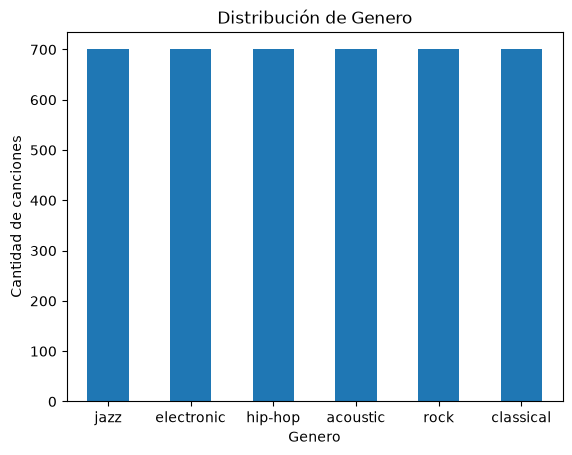

In [9]:
# Distribución de géneros
df["Expected"].value_counts().plot(kind="bar")

plt.title("Distribución de Genero")
plt.xlabel("Genero")
plt.ylabel("Cantidad de canciones")
plt.xticks(rotation=0)
plt.show()


El conjunto de datos se encuentra perfectamente balanceado, ya que los seis géneros contienen la misma cantidad de canciones. Esto es positivo para el entrenamiento, porque evita que el modelo tienda a favorecer a una clase por tener más ejemplos que las demás.

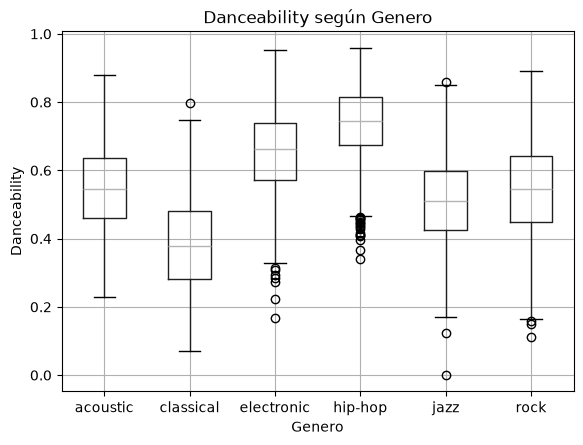

In [10]:
# Boxplot de Danceability según Genero
df.boxplot(
    column="danceability",
    by="Expected"
)

plt.title("Danceability según Genero")
plt.suptitle("")
plt.xlabel("Genero")
plt.ylabel("Danceability")
plt.show()

La variable `danceability` muestra diferencias claras entre algunos géneros. `hip-hop` presenta los valores más altos, seguido por `electronic`, mientras que `classical` tiene los valores más bajos. Sin embargo, algunos géneros como `acoustic`, `jazz` y `rock` presentan bastante superposición.

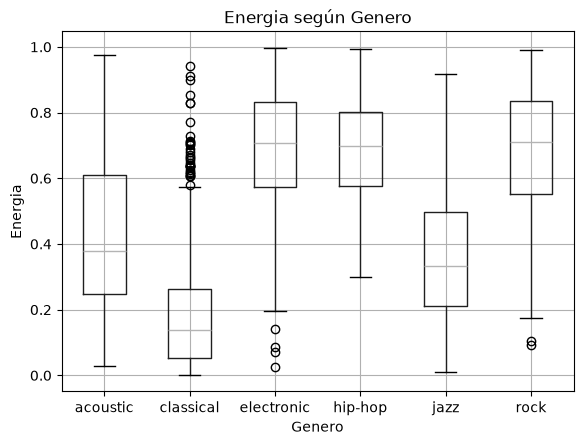

In [11]:
# Boxplot de Energy según Genero
df.boxplot(
    column="energy",
    by="Expected"
)

plt.title("Energia según Genero")
plt.suptitle("")
plt.xlabel("Genero")
plt.ylabel("Energia")
plt.show()

La duración también presenta diferencias entre los géneros. `electronic`, `hip-hop` y `rock` tienden a tener valores más altos, mientras que `classical` y `jazz` concentran valores más bajos. Aun así, existe cierta superposición entre varias clases.

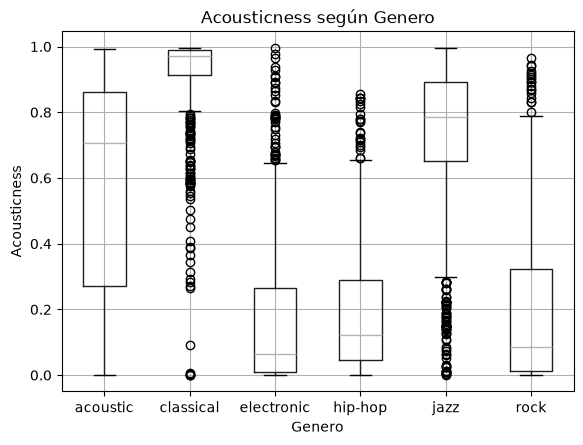

In [12]:
# Boxplot de Acousticness según Genero
df.boxplot(
    column="acousticness",
    by="Expected"
)

plt.title("Acousticness según Genero")
plt.suptitle("")
plt.xlabel("Genero")
plt.ylabel("Acousticness")
plt.show()

`acousticness` parece ser una de las variables más útiles para diferenciar géneros. `classical`, `jazz` y `acoustic` presentan valores generalmente altos, mientras que `electronic`, `hip-hop` y `rock` se concentran principalmente en valores bajos. Esto sugiere que puede ser una característica importante para la clasificación.

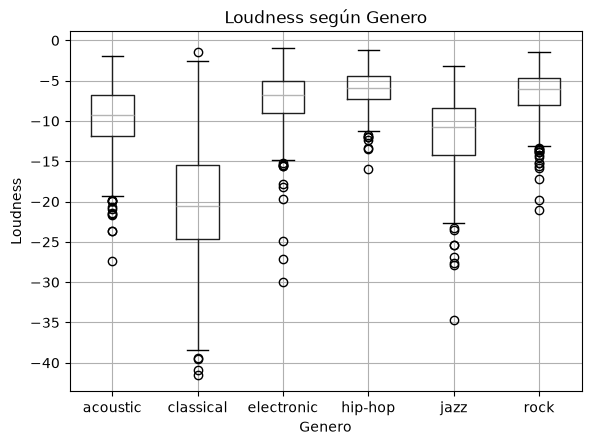

In [13]:
# Boxplot de Loudness según Genero
df.boxplot(
    column="loudness",
    by="Expected"
)

plt.title("Loudness según Genero")
plt.suptitle("")
plt.xlabel("Genero")
plt.ylabel("Loudness")
plt.show()

La variable `loudness` muestra diferencias importantes entre los géneros. `hip-hop`, `electronic` y `rock` tienden a presentar valores más altos, mientras que `classical` se concentra en valores considerablemente más bajos. Por lo tanto, puede ser una variable útil para diferenciar algunos géneros.


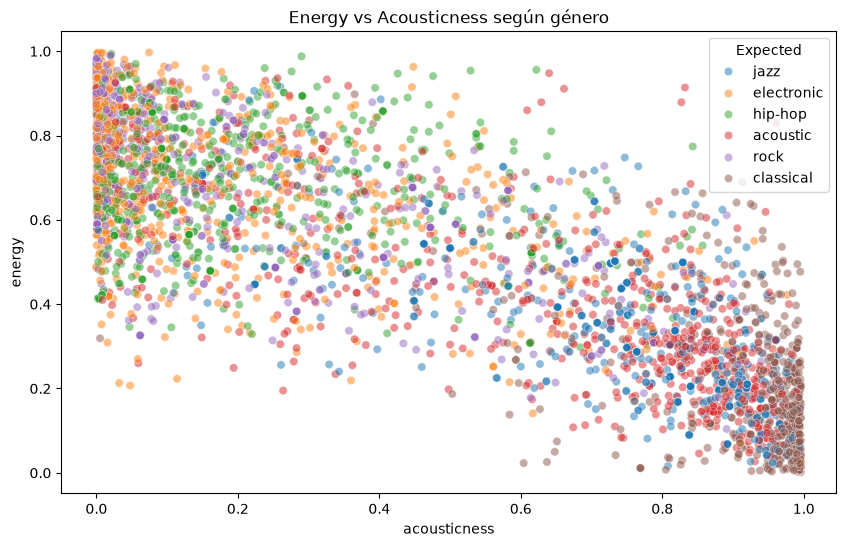

In [14]:
# Scatterplot de Energy vs Acousticness según género

import seaborn as sns
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="acousticness",
    y="energy",
    hue="Expected",
    alpha=0.5
)

plt.title("Energy vs Acousticness según género")
plt.show()

Se observa una relación inversa bastante clara entre `energy` y `acousticness`: las canciones más acústicas tienden a tener menor energía. Además, algunos géneros ocupan regiones distintas del gráfico, por ejemplo `classical` aparece principalmente con alta acousticness y baja energy, mientras que `hip-hop` y `electronic` suelen presentar mayor energy y menor acousticness.

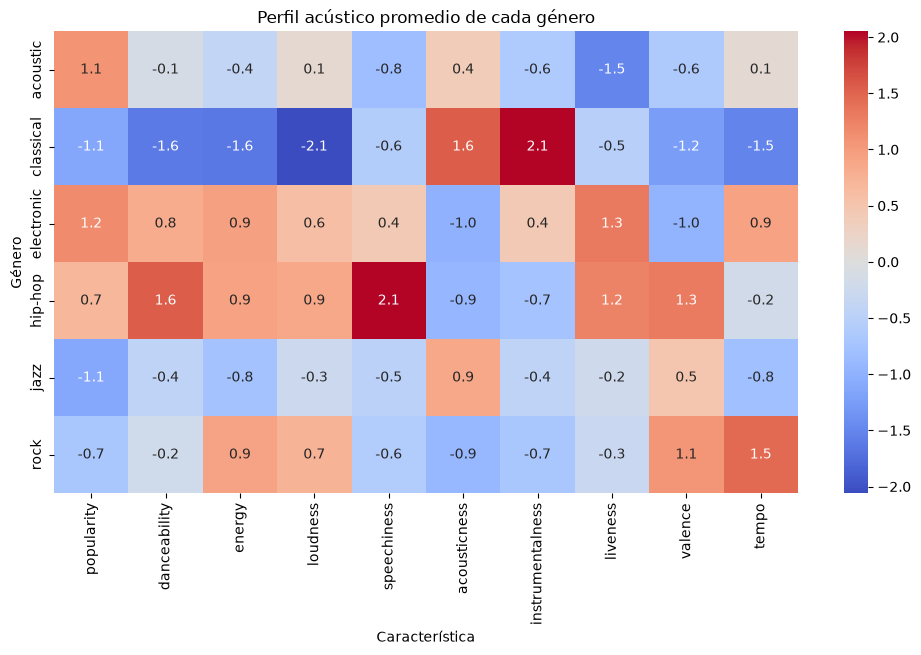

In [15]:
# Heatmap de características promedio por género
from sklearn.preprocessing import StandardScaler

features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

medias = df.groupby("Expected")[features].mean()

scaler = StandardScaler()
medias_scaled = pd.DataFrame(
    scaler.fit_transform(medias),
    index=medias.index,
    columns=medias.columns
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    medias_scaled,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".1f"
)

plt.title("Perfil acústico promedio de cada género")
plt.xlabel("Característica")
plt.ylabel("Género")
plt.show()

El heatmap permite observar que cada género presenta un perfil diferente. `classical` se destaca por su alta `acousticness` e `instrumentalness`, mientras que `hip-hop` presenta valores altos de `danceability`, `speechiness` y `valence`. `Electronic` y `rock` muestran mayor `energy` y `loudness`. 

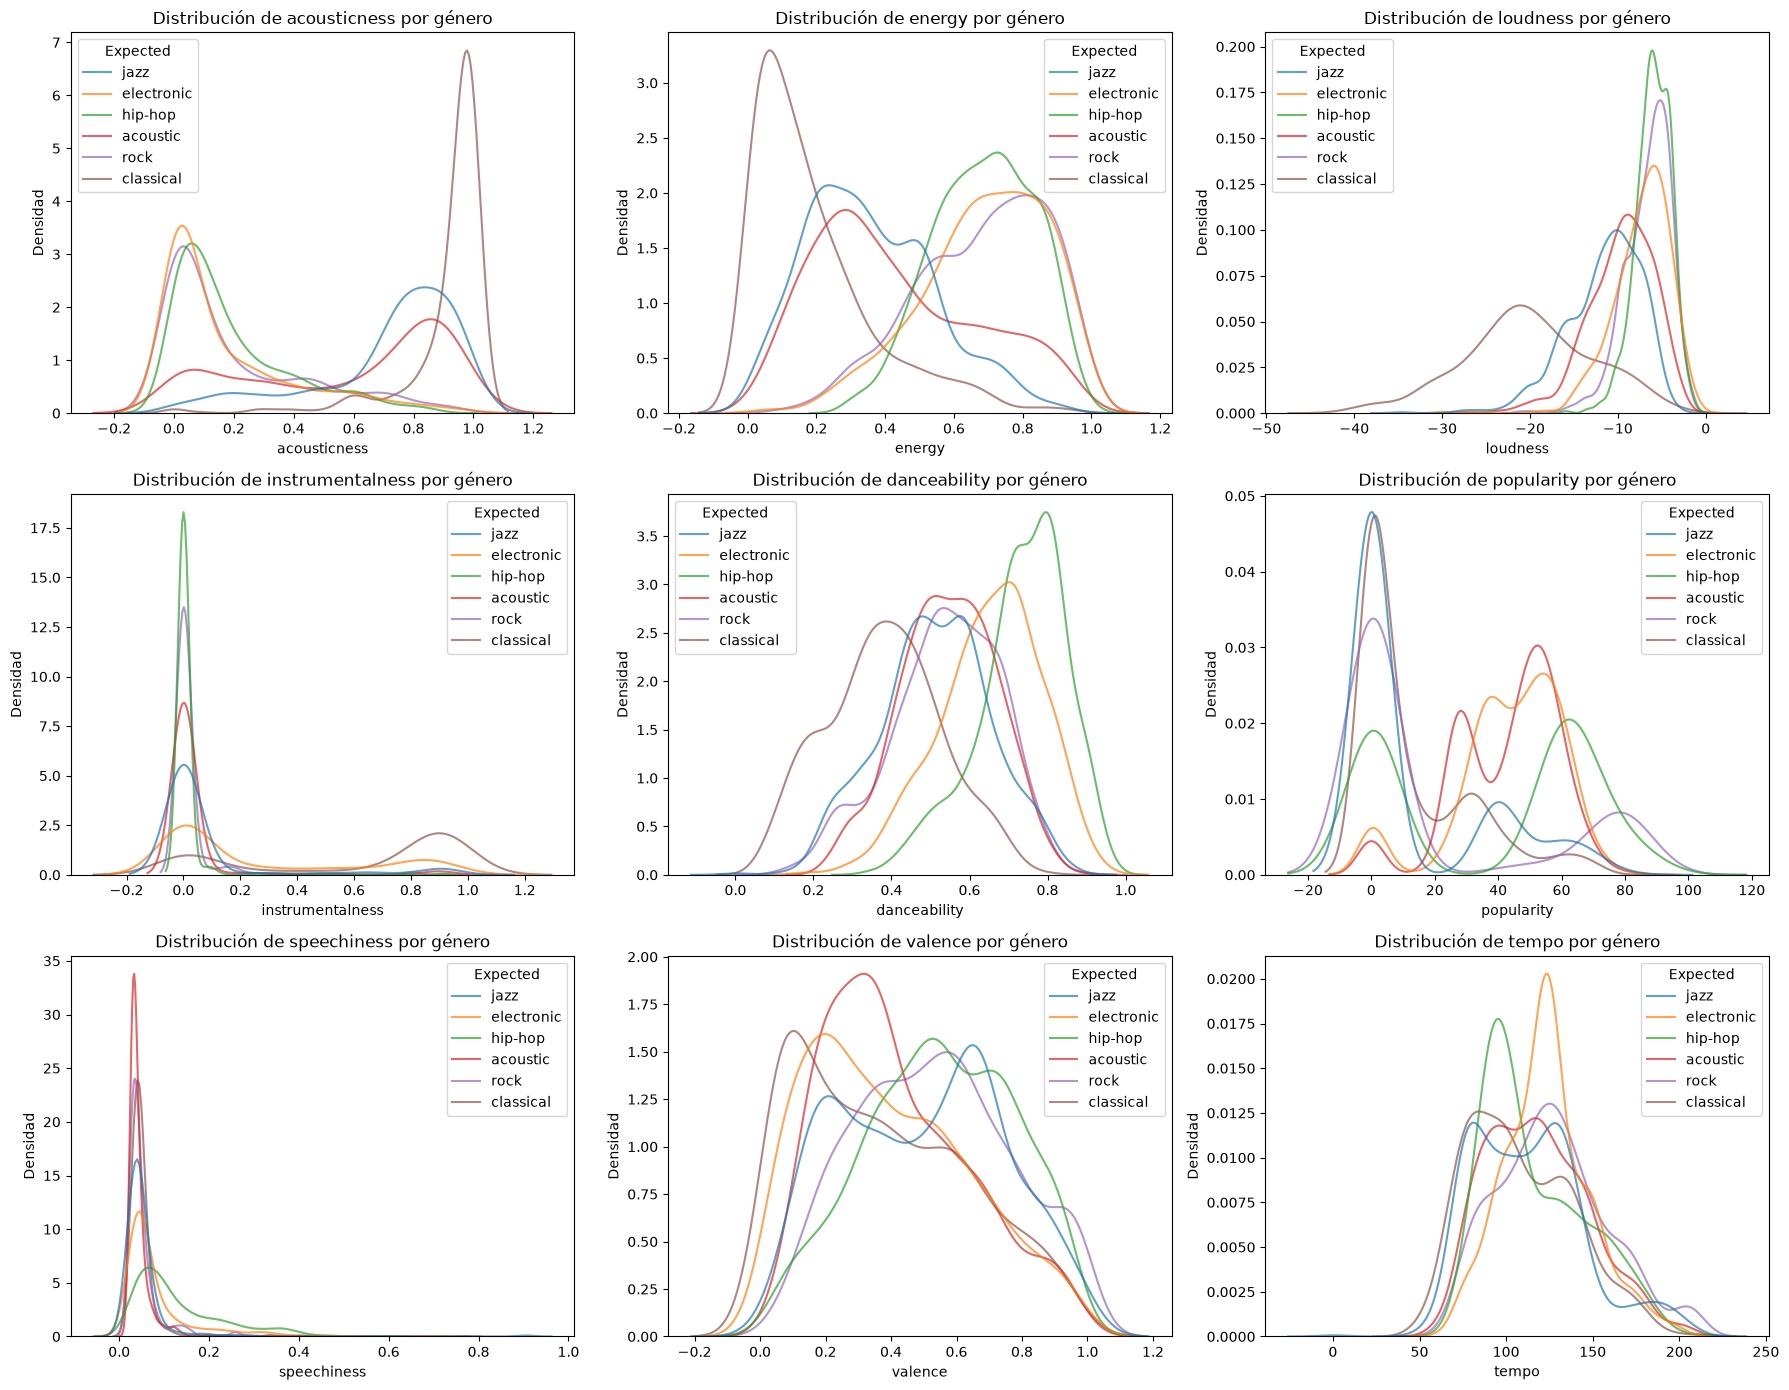

In [16]:
# Gráficos de distribución de variables por género
import matplotlib.pyplot as plt
import seaborn as sns

# Variables más importantes para diferenciar géneros
variables = [
    "acousticness",
    "energy",
    "loudness",
    "instrumentalness",
    "danceability",
    "popularity",
    "speechiness",
    "valence",
    "tempo"
]

# Crear grilla de gráficos
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

axes = axes.flatten()

# Una distribución por variable
for i, variable in enumerate(variables):
    
    sns.kdeplot(
        data=df,
        x=variable,
        hue="Expected",
        common_norm=False,
        fill=False,
        alpha=0.7,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribución de {variable} por género")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

Las distribuciones muestran que algunas características separan mejor los géneros que otras. `acousticness`, `energy`, `loudness`, `danceability`, `instrumentalness` y `popularity` presentan diferencias visibles entre varias clases.

En cambio, variables como `valence` y `tempo` presentan una mayor superposición entre géneros, por lo que individualmente parecen tener menor capacidad para diferenciarlos.

En general, ninguna variable permite separar perfectamente todos los géneros por sí sola, por lo que será necesario combinar varias características para obtener una buena clasificación.

Como se lee este grafico? por ejemplo, la variable danceability presenta diferencias claras entre algunos géneros. Hip-hop y electronic muestran valores generalmente más altos, mientras que classical concentra valores más bajos. Sin embargo, jazz, acoustic y rock presentan distribuciones considerablemente superpuestas, por lo que esta característica por sí sola no permite diferenciar correctamente todos los géneros.

### 2. Preprocesamiento de los datos

#### Eliminación de columnas no informativas

La variable `Id` funciona únicamente como identificador de cada canción y no contiene información útil para predecir el género musical. La eliminamos.

#### Separación entre variables predictoras y variable objetivo

Separamos la variable objetivo `Expected` del resto de las características. De esta manera, utilizamos las variables acústicas como entrada del modelo (`X`) y el género musical como etiqueta a predecir (`y`).

#### Tratamiento de variables categóricas

Algunas variables, como `explicit`, `mode`, `key` o `time_signature`, representan información categórica o discreta.

En particular, `explicit` puede transformarse a una representación numérica binaria si fuera necesario. Otras variables como `key` y `time_signature` ya se encuentran codificadas numéricamente, aunque sus valores representan categorías y no necesariamente una relación numérica continua.

#### Escalado de variables numéricas

Las variables del dataset se encuentran en escalas muy diferentes. Por ejemplo, `tempo` puede tomar valores superiores a 100, mientras que variables como `energy`, `danceability` o `acousticness` se encuentran aproximadamente entre 0 y 1.

Por eso, utilizamos estandarización mediante `StandardScaler`. Esto transforma las variables para que tengan media cercana a 0 y desvío estándar cercano a 1.

#### Revisión de valores faltantes

Se verificó si existían valores nulos en el dataset. En caso de encontrarlos, sería necesario imputarlos o eliminar las filas correspondientes según la cantidad y la variable afectada.

#### Revisión de valores atípicos

Durante el EDA se observaron algunos valores extremos en variables como `loudness`, `speechiness` o `duration_ms`.

Sin embargo, no se eliminaron automáticamente, ya que estos valores pueden representar canciones reales con características poco frecuentes. Eliminar estos casos podría hacer que el modelo pierda información relevante.

#### División de los datos

El conjunto proporcionado para la competencia contiene dos archivos: `train.csv` y `test.csv`.

El archivo `train.csv` contiene las etiquetas correspondientes al género musical (`Expected`), por lo que se utiliza para entrenar y evaluar los modelos. En cambio, `test.csv` no contiene la variable objetivo y se utiliza únicamente para generar las predicciones finales que serán enviadas a Kaggle.

Para poder evaluar los modelos localmente, dividimos `train.csv` en un conjunto de entrenamiento del 80% y un conjunto de validación del 20%.

La división se realizó utilizando `stratify=y` para mantener la proporción de géneros en ambos conjuntos y `random_state=42` para garantizar la reproducibilidad.

Posteriormente, la búsqueda de hiperparámetros se realiza mediante validación cruzada sobre el conjunto de entrenamiento. Una vez seleccionado el mejor modelo, se puede volver a entrenar utilizando todos los datos disponibles de `train.csv` antes de generar las predicciones sobre `test.csv`.

### 3. Modelos de Machine Learning

Para establecer una primera comparación, entrenamos dos modelos de clasificación diferentes: **Logistic Regression** y **Random Forest**.

La elección de estos modelos permite comparar dos enfoques distintos. Logistic Regression construye una relación lineal entre las características de las canciones y las probabilidades de pertenecer a cada género, mientras que Random Forest utiliza múltiples árboles de decisión y puede capturar relaciones no lineales e interacciones más complejas entre las variables.

Para Logistic Regression utilizamos los datos previamente estandarizados, ya que este modelo es sensible a la escala de las variables.

En cambio, Random Forest no requiere escalado, por lo que se entrenó utilizando las variables en su escala original.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Variables predictoras y target
X = df.drop(columns=["Expected", "Id"])
y = df["Expected"]

# División estratificada
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



Buscamos el mejor escalador para el modelo de Regresion Logistica

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
def mejor_scaler(modelo):
    # Guardamos los escaladores, que vamos a usar para comparar
    scalers = {
        "StandardScaler": StandardScaler(),
        "MinMaxScaler": MinMaxScaler(),
        "RobustScaler": RobustScaler()
    }

    mejores_resultados = {"nombre": None, "instancia": None, "f1-score": -1}

    # 2. Hacemos un loop para evaluar cuál escalador obtiene el mejor desempeño 
    # comparamos los scalers utilizando únicamente el conjunto de validación. El conjunto de test se reserva exclusivamente para la evaluación final del modelo y así evitamos Data Leakage.
    for nombre, scaler in scalers.items():

        # Creamos un pipeline temporal para transformar los datos numéricos de train y validation

        pipe_temp = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", scaler)
        ])

        # Seleccionamos las columnas numéricas para este test
        X_train_prueba = pipe_temp.fit_transform(X_train)
        X_val_prueba = pipe_temp.transform(X_valid)
        
        modelo.fit(X_train_prueba, y_train)
        
        # Evaluamos usando Accuracy
        y_pred = modelo.predict(X_val_prueba)
        score = f1_score(y_valid, y_pred, average="macro")
        
        if score > mejores_resultados["f1-score"]:
            mejores_resultados["f1-score"] = score
            mejores_resultados["nombre"] = nombre
            mejores_resultados["instancia"] = scaler

    print(f"El mejor escalador fue: {mejores_resultados['nombre']} (F1-Score: {mejores_resultados['f1-score']:.4f})")

    res = mejores_resultados["instancia"]
    return res


logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)
scaler = mejor_scaler(logistic_model)
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


El mejor escalador fue: MinMaxScaler (F1-Score: 0.6743)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Crear modelo
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Entrenar
logistic_model.fit(X_train_scaled, y_train)

# Predicciones sobre validación
y_pred_logistic = logistic_model.predict(X_valid_scaled)

# F1 Macro
f1_logistic = f1_score(
    y_valid,
    y_pred_logistic,
    average="macro"
)

print("F1 Macro - Logistic Regression:", f1_logistic)

print("\nClassification Report:")
print(classification_report(y_valid, y_pred_logistic))

F1 Macro - Logistic Regression: 0.6743276909961421

Classification Report:
              precision    recall  f1-score   support

    acoustic       0.61      0.55      0.58       140
   classical       0.91      0.81      0.86       140
  electronic       0.66      0.59      0.62       140
     hip-hop       0.66      0.74      0.70       140
        jazz       0.71      0.67      0.69       140
        rock       0.55      0.68      0.61       140

    accuracy                           0.67       840
   macro avg       0.68      0.67      0.67       840
weighted avg       0.68      0.67      0.67       840



In [20]:
from sklearn.ensemble import RandomForestClassifier

# Crear modelo
random_forest_model = RandomForestClassifier(
    random_state=42,
    max_depth=40,
    max_features=0.49951030827914167,
    min_samples_split= 2,
    n_estimators= 118
)

# Entrenar
random_forest_model.fit(X_train, y_train)

# Predicciones sobre validación
y_pred_rf = random_forest_model.predict(X_valid)

# F1 Macro
f1_rf = f1_score(
    y_valid,
    y_pred_rf,
    average="macro"
)

print("F1 Macro - Random Forest:", f1_rf)

print("\nClassification Report:")
print(classification_report(y_valid, y_pred_rf))

F1 Macro - Random Forest: 0.8332371475344843

Classification Report:
              precision    recall  f1-score   support

    acoustic       0.77      0.78      0.78       140
   classical       0.92      0.87      0.89       140
  electronic       0.79      0.85      0.82       140
     hip-hop       0.80      0.91      0.85       140
        jazz       0.89      0.75      0.81       140
        rock       0.84      0.84      0.84       140

    accuracy                           0.83       840
   macro avg       0.84      0.83      0.83       840
weighted avg       0.84      0.83      0.83       840



### XGBoost

Además de Logistic Regression y Random Forest, se probó un modelo XGBoost, el cual permite modelar relaciones no lineales entre las variables.

Primero se entrenó un modelo base, utilizando los hiperparámetros por defecto, con el objetivo de obtener un nuevo punto de referencia antes de realizar la búsqueda de hiperparámetros.

In [21]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

# Codificamos las clases a números
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)

# Modelo base
xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

# Entrenamiento
xgb_model.fit(X_train, y_train_encoded)

# Predicción
y_pred_xgb_encoded = xgb_model.predict(X_valid)

# Volvemos a los nombres originales de los géneros
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

# F1 Macro
f1_xgb = f1_score(
    y_valid,
    y_pred_xgb,
    average="macro"
)

print("F1 Macro - XGBoost:", f1_xgb)

F1 Macro - XGBoost: 0.847588469992684


El modelo XGBoost base obtuvo un **F1-Macro de 0.8476** sobre el conjunto de validación.

Este resultado fue superior al obtenido por Random Forest, cuyo F1-Macro fue aproximadamente 0.8351. Por lo tanto, XGBoost se convirtió en el modelo con mejor desempeño hasta este punto.

A partir de este resultado, se decidió realizar una búsqueda de hiperparámetros para intentar mejorar aún más su rendimiento.

#### Búsqueda de hiperparámetros de XGBoost

Para ajustar XGBoost se utilizó `RandomizedSearchCV`, explorando distintas combinaciones de hiperparámetros.

La búsqueda se realizó utilizando validación cruzada de 5 folds y optimizando `f1_macro`, que es la métrica oficial de la competencia.

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import uniform
import time
from sklearn.model_selection import ParameterSampler
import sklearn
import xgboost as xgb

param_dist_xgb = {'max_depth': list(range(1, 40)),
          'learning_rate': uniform(scale = 0.4),
          'gamma': uniform(scale = 2),
          'reg_lambda': uniform(scale = 5),        # Parámetro de regularización.
          'subsample': uniform(0.5, 0.5),          # Entre 0.5 y 1.
          'min_child_weight': uniform(scale = 5),
          'colsample_bytree': uniform(0.75, 0.25), # Entre 0.75 y 1.
          'n_estimators': list(range(1, 1000))
         }

random_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),
    param_distributions=param_dist_xgb,
    n_iter=50,
    scoring="f1_macro",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_xgb.fit(X_train, y_train_encoded)

print("Mejores hiperparámetros:")
print(random_xgb.best_params_)

print("\nMejor F1 Macro promedio en CV:")
print(random_xgb.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores hiperparámetros:
{'colsample_bytree': np.float64(0.8522382361035674), 'gamma': np.float64(0.34658864014169155), 'learning_rate': np.float64(0.06257481706843442), 'max_depth': 34, 'min_child_weight': np.float64(1.198936795787016), 'n_estimators': 118, 'reg_lambda': np.float64(3.5729796135003116), 'subsample': np.float64(0.8300986883588657)}

Mejor F1 Macro promedio en CV:
0.8261994631435046


In [23]:
best_xgb = random_xgb.best_estimator_

y_pred_xgb_tuned_encoded = best_xgb.predict(X_valid)

y_pred_xgb_tuned = label_encoder.inverse_transform(
    y_pred_xgb_tuned_encoded
)

f1_xgb_tuned = f1_score(
    y_valid,
    y_pred_xgb_tuned,
    average="macro"
)

print("F1 Macro - XGBoost tuned:", f1_xgb_tuned)

xgb_model_tuned = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **random_xgb.best_params_
)

F1 Macro - XGBoost tuned: 0.8474108549717404


In [24]:
print("Random Forest:", f1_rf)
print("XGBoost baseline:", f1_xgb)
print("XGBoost tuned:", f1_xgb_tuned)

Random Forest: 0.8332371475344843
XGBoost baseline: 0.847588469992684
XGBoost tuned: 0.8474108549717404


#### Resultado del ajuste de hiperparámetros

El modelo XGBoost base obtuvo un F1-Macro de **0.8476**, mientras que el modelo ajustado mediante `RandomizedSearchCV` obtuvo aproximadamente **0.851**.

Por lo tanto, la búsqueda de hiperparámetros si produjo una mejora sobre el conjunto de validación.

En consecuencia, hasta este punto se elige el **XGBoost tuned** como el modelo con mejor rendimiento, con un F1-Macro de 0.851.

In [25]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [26]:
from sklearn.model_selection import cross_val_score

scores_logistic = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Logistic Regression")
print("F1 por fold:", scores_logistic)
print("F1 promedio:", scores_logistic.mean())
print("Desvío:", scores_logistic.std())

Logistic Regression
F1 por fold: [0.65583802 0.60497518 0.66069505 0.6453441  0.67908088]
F1 promedio: 0.6491866460767712
Desvío: 0.02465671829554278


In [27]:
scores_rf = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Random Forest")
print("F1 por fold:", scores_rf)
print("F1 promedio:", scores_rf.mean())
print("Desvío:", scores_rf.std())

Random Forest
F1 por fold: [0.80471386 0.79998264 0.80813201 0.82467707 0.83138462]
F1 promedio: 0.8137780392231969
Desvío: 0.012108930502960689


In [28]:
scores_xgb = cross_val_score(
    xgb_model_tuned,
    X_train,
    y_train_encoded,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("XGBoost")
print("F1 por fold:", scores_xgb)
print("F1 promedio:", scores_xgb.mean())
print("Desvío:", scores_xgb.std())

XGBoost
F1 por fold: [0.8245668  0.80991963 0.82817858 0.82846299 0.82962462]
F1 promedio: 0.8241505232481522
Desvío: 0.007314094515129537


In [29]:
resultados_model_selection = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "F1 Macro promedio": [
        scores_logistic.mean(),
        scores_rf.mean(),
        scores_xgb.mean()
    ],
    "Desvío": [
        scores_logistic.std(),
        scores_rf.std(),
        scores_xgb.std()
    ]
})

resultados_model_selection.sort_values(
    "F1 Macro promedio",
    ascending=False
)

,Modelo,F1 Macro promedio,Desvío
2,XGBoost,0.824151,0.007314
1,Random Forest,0.813778,0.012109
0,Logistic Regression,0.649187,0.024657


#### Conclusión del Model Selection

A partir de la validación cruzada estratificada de 5 folds, XGBoost obtuvo el mejor rendimiento promedio, con un **F1-Macro de 0.820** y un desvío estándar de aproximadamente **0.0109**.

Random Forest obtuvo un F1-Macro promedio de **0.8139**, mientras que Logistic Regression presentó un rendimiento considerablemente menor, con un promedio de **0.01377**.

Además de obtener el mejor F1-Macro promedio, XGBoost presentó el menor desvío entre folds, lo que indica un comportamiento más estable frente a distintas particiones de los datos.

Por este motivo, XGBoost fue seleccionado como el modelo final para continuar con las siguientes etapas del trabajo.

In [30]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# =========================================================
# 1. PREPARAR TRAIN COMPLETO
# =========================================================

X_full = df.drop(columns=["Expected", "Id"])
y_full = df["Expected"]


# Codificamos los géneros
label_encoder_final = LabelEncoder()
y_full_encoded = label_encoder_final.fit_transform(y_full)

# =========================================================
# 2. ENTRENAR MODELO FINAL
# =========================================================

xgb_final = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **random_xgb.best_params_
)
xgb_final.fit(
    X_full,
    y_full_encoded
)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.8522382361035674)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-

In [31]:
# =========================================================
# 3. PREPARAR TEST DE KAGGLE
# =========================================================

test_kaggle = pd.read_csv("test.csv")

X_test_kaggle = test_kaggle.drop(columns=["Id"])


In [32]:
# =========================================================
# 4. PREDECIR TEST.CSV
# =========================================================

pred_encoded = xgb_final.predict(
    X_test_kaggle
)

pred_generos = label_encoder_final.inverse_transform(
    pred_encoded
)

In [33]:
# =========================================================
# 5. CREAR SUBMISSION
# =========================================================

submission = pd.DataFrame({
    "Id": test_kaggle["Id"],
    "Expected": pred_generos
})

submission.to_csv(
    "submission_xgboost_tuned2.csv",
    index=False
)

submission.head()

,Id,Expected
0,3793,acoustic
1,5701,acoustic
2,2721,electronic
3,4079,hip-hop
4,479,electronic


F1 Macro OOF: 0.8304018672746469

Classification report:
              precision    recall  f1-score   support

    acoustic       0.77      0.79      0.78       700
   classical       0.90      0.88      0.89       700
  electronic       0.78      0.80      0.79       700
     hip-hop       0.84      0.89      0.87       700
        jazz       0.82      0.76      0.79       700
        rock       0.86      0.85      0.85       700

    accuracy                           0.83      4200
   macro avg       0.83      0.83      0.83      4200
weighted avg       0.83      0.83      0.83      4200



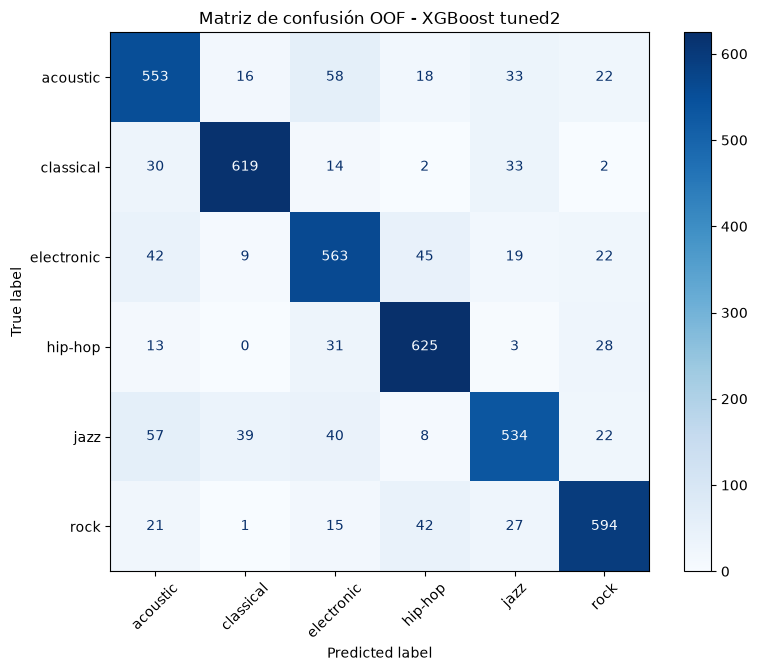

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# =========================================================
# DATOS COMPLETOS DE TRAIN
# =========================================================

X = df.drop(columns=["Expected", "Id"])
y = df["Expected"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# =========================================================
# MISMA CONFIGURACIÓN DE TUNED2
# =========================================================

modelo_oof = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **random_xgb.best_params_
)

# =========================================================
# CROSS VALIDATION
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cada canción es predicha por un modelo que NO la vio al entrenar
pred_oof_encoded = cross_val_predict(
    modelo_oof,
    X,
    y_encoded,
    cv=cv,
    method="predict",
    n_jobs=-1
)

pred_oof = label_encoder.inverse_transform(pred_oof_encoded)

# =========================================================
# RESULTADOS
# =========================================================

print(
    "F1 Macro OOF:",
    f1_score(y, pred_oof, average="macro")
)

print("\nClassification report:")
print(
    classification_report(
        y,
        pred_oof
    )
)

# =========================================================
# MATRIZ DE CONFUSIÓN
# =========================================================

cm = confusion_matrix(
    y,
    pred_oof,
    labels=label_encoder.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Matriz de confusión OOF - XGBoost tuned2")
plt.show()

In [35]:
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

from xgboost import XGBClassifier


# =========================================================
# 1. DATOS
# =========================================================

X = df.drop(columns=["Expected", "Id"])
y = df["Expected"]

label_encoder_blend = LabelEncoder()
y_encoded = label_encoder_blend.fit_transform(y)


# =========================================================
# 2. MODELOS
# =========================================================

# XGBoost tuned2
xgb_blend = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **random_xgb.best_params_
)

# Random Forest
rf_blend = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)


# =========================================================
# 3. CROSS VALIDATION
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =========================================================
# 4. PROBABILIDADES OOF
# =========================================================

prob_xgb = cross_val_predict(
    xgb_blend,
    X,
    y_encoded,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)

prob_rf = cross_val_predict(
    rf_blend,
    X,
    y_encoded,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)


# =========================================================
# 5. BUSCAR MEJOR PESO
# =========================================================

resultados = []

for peso_xgb in np.arange(0.50, 1.01, 0.02):

    peso_rf = 1 - peso_xgb

    prob_blend = (
        peso_xgb * prob_xgb
        + peso_rf * prob_rf
    )

    pred_blend_encoded = np.argmax(
        prob_blend,
        axis=1
    )

    f1 = f1_score(
        y_encoded,
        pred_blend_encoded,
        average="macro"
    )

    resultados.append(
        (peso_xgb, peso_rf, f1)
    )


# =========================================================
# 6. MEJOR COMBINACIÓN
# =========================================================

resultados = sorted(
    resultados,
    key=lambda x: x[2],
    reverse=True
)

mejor_peso_xgb, mejor_peso_rf, mejor_f1 = resultados[0]

print("F1 tuned2 original: 0.8304018672746469")

print("\nMejor ensemble:")
print("Peso XGBoost:", mejor_peso_xgb)
print("Peso Random Forest:", mejor_peso_rf)
print("F1 Macro OOF:", mejor_f1)

print("\nTop 10 combinaciones:")

for resultado in resultados[:10]:
    print(resultado)

F1 tuned2 original: 0.8304018672746469

Mejor ensemble:
Peso XGBoost: 0.7400000000000002
Peso Random Forest: 0.2599999999999998
F1 Macro OOF: 0.8328267186636356

Top 10 combinaciones:
(np.float64(0.7400000000000002), np.float64(0.2599999999999998), 0.8328267186636356)
(np.float64(0.6200000000000001), np.float64(0.3799999999999999), 0.832656308394358)
(np.float64(0.7200000000000002), np.float64(0.2799999999999998), 0.8326494209156375)
(np.float64(0.5800000000000001), np.float64(0.41999999999999993), 0.8326398274222321)
(np.float64(0.6000000000000001), np.float64(0.3999999999999999), 0.8324292947924681)
(np.float64(0.7000000000000002), np.float64(0.2999999999999998), 0.8324210251144745)
(np.float64(0.54), np.float64(0.45999999999999996), 0.8324087932240835)
(np.float64(0.5), np.float64(0.5), 0.8321914535895356)
(np.float64(0.6600000000000001), np.float64(0.33999999999999986), 0.8321671827528624)
(np.float64(0.56), np.float64(0.43999999999999995), 0.8321578200768217)


In [36]:
import numpy as np
from sklearn.metrics import f1_score

# =========================================================
# OPTIMIZAR PESOS POR CLASE PARA F1 MACRO
# =========================================================

rng = np.random.default_rng(42)

mejor_f1 = 0
mejores_pesos = None

# Probabilidades OOF del XGBoost tuned2
# prob_xgb debe tener shape (4200, 6)

for _ in range(10000):

    # Buscamos correcciones relativamente pequeñas
    pesos = rng.uniform(
        0.85,
        1.15,
        size=prob_xgb.shape[1]
    )

    prob_ajustadas = prob_xgb * pesos

    pred = np.argmax(
        prob_ajustadas,
        axis=1
    )

    f1 = f1_score(
        y_encoded,
        pred,
        average="macro"
    )

    if f1 > mejor_f1:
        mejor_f1 = f1
        mejores_pesos = pesos.copy()


print("F1 tuned2 original:")
print(
    f1_score(
        y_encoded,
        np.argmax(prob_xgb, axis=1),
        average="macro"
    )
)

print("\nMejor F1 ajustando probabilidades:")
print(mejor_f1)

print("\nPesos encontrados:")

for clase, peso in zip(
    label_encoder_blend.classes_,
    mejores_pesos
):
    print(clase, ":", round(peso, 4))

F1 tuned2 original:
0.8304018672746469

Mejor F1 ajustando probabilidades:
0.834294766158835

Pesos encontrados:
acoustic : 1.1228
classical : 1.0791
electronic : 0.9569
hip-hop : 1.1452
jazz : 0.9433
rock : 0.9612


In [37]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# =========================================================
# 1. TRAIN COMPLETO
# =========================================================

X_full = df.drop(columns=["Expected", "Id"])
y_full = df["Expected"]

label_encoder_final = LabelEncoder()
y_full_encoded = label_encoder_final.fit_transform(y_full)

print("Orden de clases:")
print(label_encoder_final.classes_)

# =========================================================
# 2. MISMO XGBOOST TUNED2
# =========================================================

xgb_final = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **random_xgb.best_params_
)

xgb_final.fit(
    X_full,
    y_full_encoded
)

# =========================================================
# 3. TEST KAGGLE
# =========================================================

test_kaggle = pd.read_csv("test.csv")

X_test = test_kaggle.drop(columns=["Id"])

# =========================================================
# 4. PROBABILIDADES
# =========================================================

prob_test = xgb_final.predict_proba(X_test)

# =========================================================
# 5. PESOS ENCONTRADOS CON OOF
# =========================================================

pesos_clases = np.array([
    1.1228,  # acoustic
    1.0791,  # classical
    0.9569,  # electronic
    1.1452,  # hip-hop
    0.9433,  # jazz
    0.9612   # rock
])

# Aplicamos los pesos
prob_test_ajustada = prob_test * pesos_clases

# Elegimos la clase con mayor probabilidad ajustada
pred_encoded = np.argmax(
    prob_test_ajustada,
    axis=1
)

pred_generos = label_encoder_final.inverse_transform(
    pred_encoded
)

# =========================================================
# 6. SUBMISSION
# =========================================================

submission_pesos = pd.DataFrame({
    "Id": test_kaggle["Id"],
    "Expected": pred_generos
})

submission_pesos.to_csv(
    "submission_xgboost_class_weights.csv",
    index=False
)

print("\nShape:", submission_pesos.shape)
print("\nDistribución:")
print(submission_pesos["Expected"].value_counts())

display(submission_pesos.head())

Orden de clases:
['acoustic' 'classical' 'electronic' 'hip-hop' 'jazz' 'rock']

Shape: (1800, 2)

Distribución:
Expected
acoustic      318
hip-hop       318
rock          308
classical     298
electronic    283
jazz          275
Name: count, dtype: int64


,Id,Expected
0,3793,acoustic
1,5701,acoustic
2,2721,electronic
3,4079,hip-hop
4,479,electronic


In [38]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

# =========================================================
# 1. DATOS
# =========================================================

X = df.drop(columns=["Expected", "Id"])
y = df["Expected"]

label_encoder_gb = LabelEncoder()
y_encoded = label_encoder_gb.fit_transform(y)

# =========================================================
# 2. MODELO
# =========================================================

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# =========================================================
# 3. CROSS VALIDATION OOF
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pred_gb_encoded = cross_val_predict(
    gb_model,
    X,
    y_encoded,
    cv=cv,
    method="predict",
    n_jobs=-1
)

pred_gb = label_encoder_gb.inverse_transform(
    pred_gb_encoded
)

# =========================================================
# 4. RESULTADOS
# =========================================================

f1_gb = f1_score(
    y,
    pred_gb,
    average="macro"
)

print("F1 tuned2 OOF: 0.8304018672746469")
print("F1 Gradient Boosting OOF:", f1_gb)

print("\nClassification Report:")
print(
    classification_report(
        y,
        pred_gb
    )
)

F1 tuned2 OOF: 0.8304018672746469
F1 Gradient Boosting OOF: 0.8159453198134071

Classification Report:
              precision    recall  f1-score   support

    acoustic       0.75      0.79      0.77       700
   classical       0.92      0.87      0.89       700
  electronic       0.79      0.78      0.79       700
     hip-hop       0.84      0.87      0.86       700
        jazz       0.79      0.73      0.76       700
        rock       0.82      0.85      0.83       700

    accuracy                           0.82      4200
   macro avg       0.82      0.82      0.82      4200
weighted avg       0.82      0.82      0.82      4200



In [39]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from scipy.stats import uniform

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_dist_xgb_2 = {
    "n_estimators": [100, 150, 200, 250, 300, 400],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.03, 0.05, 0.08, 0.1, 0.15, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5, 8],
    "gamma": [0, 0.05, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.01, 0.05, 0.1, 0.5],
    "reg_lambda": [0.5, 1, 2, 3, 5]
}

xgb_search_2 = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),
    param_distributions=param_dist_xgb_2,
    n_iter=100,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search_2.fit(X, y_encoded)

print("Mejor F1 CV:")
print(xgb_search_2.best_score_)

print("\nMejores parámetros:")
print(xgb_search_2.best_params_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejor F1 CV:
0.8376024072663109

Mejores parámetros:
{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 2, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.9}


In [40]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

# =========================================================
# 1. DATOS
# =========================================================

X_cat = df.drop(columns=["Expected", "Id"]).copy()
y_cat = df["Expected"]

label_encoder_cat = LabelEncoder()
y_cat_encoded = label_encoder_cat.fit_transform(y_cat)

# =========================================================
# 2. COLUMNAS CATEGÓRICAS
# =========================================================

categorical_cols = [
    "explicit",
    "key",
    "mode",
    "time_signature"
]

# CatBoost necesita los índices de esas columnas
cat_features_idx = [
    X_cat.columns.get_loc(col)
    for col in categorical_cols
]

# =========================================================
# 3. MODELO CATBOOST
# =========================================================

cat_model = CatBoostClassifier(
    loss_function="MultiClass",
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

# =========================================================
# 4. CROSS VALIDATION OOF
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pred_cat_encoded = cross_val_predict(
    cat_model,
    X_cat,
    y_cat_encoded,
    cv=cv,
    method="predict",
    params={"cat_features": cat_features_idx},
    n_jobs=1
)

pred_cat_encoded = pred_cat_encoded.ravel().astype(int)

pred_cat = label_encoder_cat.inverse_transform(
    pred_cat_encoded
)

# =========================================================
# 5. RESULTADOS
# =========================================================

f1_cat = f1_score(
    y_cat,
    pred_cat,
    average="macro"
)

print("F1 tuned2 OOF: 0.8304018672746469")
print("F1 tuned3 CV: 0.8376024072663109")
print("F1 CatBoost OOF:", f1_cat)

print("\nClassification Report:")
print(
    classification_report(
        y_cat,
        pred_cat
    )
)

F1 tuned2 OOF: 0.8304018672746469
F1 tuned3 CV: 0.8376024072663109
F1 CatBoost OOF: 0.8256329077910252

Classification Report:
              precision    recall  f1-score   support

    acoustic       0.75      0.80      0.77       700
   classical       0.91      0.88      0.89       700
  electronic       0.81      0.81      0.81       700
     hip-hop       0.85      0.89      0.87       700
        jazz       0.80      0.73      0.77       700
        rock       0.85      0.84      0.84       700

    accuracy                           0.83      4200
   macro avg       0.83      0.83      0.83      4200
weighted avg       0.83      0.83      0.83      4200



In [42]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier


# =========================================================
# 1. TRANSFORMER PARA CLIPPEAR SOLO VARIABLES CONTINUAS
# =========================================================

class QuantileClipper(BaseEstimator, TransformerMixin):

    def __init__(self, columns, lower=0.01, upper=0.99):
        self.columns = columns
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = X.copy()

        self.lower_bounds_ = X[self.columns].quantile(
            self.lower
        )

        self.upper_bounds_ = X[self.columns].quantile(
            self.upper
        )

        return self

    def transform(self, X):
        X = X.copy()

        X[self.columns] = X[self.columns].clip(
            lower=self.lower_bounds_,
            upper=self.upper_bounds_,
            axis=1
        )

        return X


# =========================================================
# 2. DATOS
# =========================================================

X = df.drop(columns=["Expected", "Id"]).copy()
y = df["Expected"]

label_encoder_clip = LabelEncoder()
y_encoded = label_encoder_clip.fit_transform(y)


# =========================================================
# 3. VARIABLES SOBRE LAS QUE HACEMOS CLIPPING
# =========================================================

continuous_features = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]


# =========================================================
# 4. XGBOOST TUNED3
# =========================================================

xgb_clip = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **xgb_search_2.best_params_
)


# =========================================================
# 5. PIPELINE
# =========================================================

pipeline_clip = Pipeline([
    (
        "clipper",
        QuantileClipper(
            columns=continuous_features,
            lower=0.01,
            upper=0.99
        )
    ),
    (
        "model",
        xgb_clip
    )
])


# =========================================================
# 6. CROSS VALIDATION
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pred_clip_encoded = cross_val_predict(
    pipeline_clip,
    X,
    y_encoded,
    cv=cv,
    method="predict",
    n_jobs=-1
)

pred_clip = label_encoder_clip.inverse_transform(
    pred_clip_encoded
)


# =========================================================
# 7. RESULTADOS
# =========================================================

f1_clip = f1_score(
    y,
    pred_clip,
    average="macro"
)

print("F1 tuned3 CV:", xgb_search_2.best_score_)
print("F1 tuned3 + clipping:", f1_clip)

print("\nClassification Report:")
print(
    classification_report(
        y,
        pred_clip
    )
)

F1 tuned3 CV: 0.8376024072663109
F1 tuned3 + clipping: 0.8345163338504427

Classification Report:
              precision    recall  f1-score   support

    acoustic       0.76      0.80      0.78       700
   classical       0.92      0.87      0.90       700
  electronic       0.79      0.81      0.80       700
     hip-hop       0.86      0.90      0.88       700
        jazz       0.82      0.78      0.80       700
        rock       0.86      0.85      0.86       700

    accuracy                           0.83      4200
   macro avg       0.84      0.83      0.83      4200
weighted avg       0.84      0.83      0.83      4200



In [43]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier


# =========================================================
# 1. DATOS
# =========================================================

X = df.drop(columns=["Expected", "Id"])
y = df["Expected"]

label_encoder_fs = LabelEncoder()
y_encoded = label_encoder_fs.fit_transform(y)


# =========================================================
# 2. MODELO TUNED3 SOBRE TODO TRAIN
# =========================================================

xgb_fs = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **xgb_search_2.best_params_
)

xgb_fs.fit(X, y_encoded)


# =========================================================
# 3. IMPORTANCIA DE FEATURES
# =========================================================

importancias = pd.Series(
    xgb_fs.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Ranking de variables:")
print(importancias)


# =========================================================
# 4. CROSS VALIDATION
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =========================================================
# 5. PROBAR DISTINTAS CANTIDADES DE FEATURES
# =========================================================

resultados_fs = []

for n_features in range(8, len(X.columns) + 1):

    features = importancias.index[:n_features]

    modelo = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        **xgb_search_2.best_params_
    )

    scores = cross_val_score(
        modelo,
        X[features],
        y_encoded,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    resultados_fs.append({
        "n_features": n_features,
        "f1_mean": scores.mean(),
        "f1_std": scores.std(),
        "features": list(features)
    })


# =========================================================
# 6. RESULTADOS
# =========================================================

resultados_fs_df = pd.DataFrame(resultados_fs)

print("\nResultados:")
print(
    resultados_fs_df[
        ["n_features", "f1_mean", "f1_std"]
    ].sort_values(
        "f1_mean",
        ascending=False
    )
)

mejor = resultados_fs_df.loc[
    resultados_fs_df["f1_mean"].idxmax()
]

print("\nMejor cantidad de features:")
print(mejor["n_features"])

print("\nMejor F1 CV:")
print(mejor["f1_mean"])

print("\nFeatures seleccionadas:")
print(mejor["features"])

print("\nF1 tuned3 con todas las variables:")
print(xgb_search_2.best_score_)

Ranking de variables:
popularity          0.159500
acousticness        0.132432
loudness            0.108231
instrumentalness    0.096029
danceability        0.083310
speechiness         0.066060
explicit            0.064306
mode                0.061758
energy              0.059568
duration_ms         0.040788
valence             0.031425
liveness            0.025007
tempo               0.024407
key                 0.023816
time_signature      0.023361
dtype: float32

Resultados:
   n_features   f1_mean    f1_std
7          15  0.837338  0.006637
4          12  0.837122  0.007698
6          14  0.835154  0.006544
5          13  0.833954  0.006807
3          11  0.830362  0.007847
2          10  0.825533  0.006747
1           9  0.813773  0.003798
0           8  0.809614  0.007665

Mejor cantidad de features:
15

Mejor F1 CV:
0.8373377414750879

Features seleccionadas:
['popularity', 'acousticness', 'loudness', 'instrumentalness', 'danceability', 'speechiness', 'explicit', 'mode', 'ener

In [44]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# =========================================================
# 1. DATOS
# =========================================================

X = df.drop(columns=["Expected", "Id"])
y = df["Expected"]

label_encoder_ada = LabelEncoder()
y_encoded = label_encoder_ada.fit_transform(y)

# =========================================================
# 2. CROSS VALIDATION
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================================
# 3. PROBAR VARIAS CONFIGURACIONES
# =========================================================

resultados_ada = []

for depth in [1, 2, 3]:
    for n_estimators in [50, 100, 200, 300]:
        for learning_rate in [0.03, 0.05, 0.1, 0.3, 0.5]:

            base_tree = DecisionTreeClassifier(
                max_depth=depth,
                random_state=42
            )

            modelo = AdaBoostClassifier(
                estimator=base_tree,
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                random_state=42
            )

            scores = cross_val_score(
                modelo,
                X,
                y_encoded,
                cv=cv,
                scoring="f1_macro",
                n_jobs=-1
            )

            resultados_ada.append({
                "depth": depth,
                "n_estimators": n_estimators,
                "learning_rate": learning_rate,
                "f1_mean": scores.mean(),
                "f1_std": scores.std()
            })

# =========================================================
# 4. RESULTADOS
# =========================================================

resultados_ada_df = pd.DataFrame(resultados_ada)

print(
    resultados_ada_df.sort_values(
        "f1_mean",
        ascending=False
    ).head(10)
)

mejor_ada = resultados_ada_df.loc[
    resultados_ada_df["f1_mean"].idxmax()
]

print("\nMejor AdaBoost:")
print(mejor_ada)

print("\nReferencia tuned3:")
print(0.8376024072663109)

    depth  n_estimators  learning_rate   f1_mean    f1_std
58      3           300           0.30  0.772467  0.018672
48      3           100           0.30  0.771197  0.016952
53      3           200           0.30  0.770548  0.016472
57      3           300           0.10  0.770106  0.018247
54      3           200           0.50  0.769625  0.018937
49      3           100           0.50  0.765038  0.022309
59      3           300           0.50  0.764757  0.020494
52      3           200           0.10  0.763771  0.015703
44      3            50           0.50  0.757104  0.012538
56      3           300           0.05  0.756869  0.014935

Mejor AdaBoost:
depth              3.000000
n_estimators     300.000000
learning_rate      0.300000
f1_mean            0.772467
f1_std             0.018672
Name: 58, dtype: float64

Referencia tuned3:
0.8376024072663109


In [45]:
import pandas as pd

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_score

from xgboost import XGBClassifier


# =========================================================
# 1. DATOS
# =========================================================

X = df.drop(columns=["Expected", "Id"]).copy()
y = df["Expected"]

# Convertimos explicit a entero para evitar problemas
X["explicit"] = X["explicit"].astype(int)

label_encoder_cluster = LabelEncoder()
y_encoded = label_encoder_cluster.fit_transform(y)


# =========================================================
# 2. CROSS VALIDATION
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =========================================================
# 3. PROBAR DISTINTAS CANTIDADES DE CLUSTERS
# =========================================================

resultados_cluster = []

for k in [4, 6, 8, 10, 12, 15]:

    # Esta rama genera K nuevas variables:
    # distancia de cada canción a cada centroide
    cluster_features = Pipeline([
        ("scaler", StandardScaler()),
        (
            "kmeans",
            KMeans(
                n_clusters=k,
                random_state=42,
                n_init=10
            )
        )
    ])

    # Conservamos las variables originales
    # y agregamos las distancias a los clusters
    features_combinadas = FeatureUnion([
        ("originales", "passthrough"),
        ("clusters", cluster_features)
    ])

    # Mismo XGBoost tuned3
    modelo = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        **xgb_search_2.best_params_
    )

    pipeline_cluster = Pipeline([
        ("features", features_combinadas),
        ("model", modelo)
    ])

    scores = cross_val_score(
        pipeline_cluster,
        X,
        y_encoded,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    resultados_cluster.append({
        "k": k,
        "f1_mean": scores.mean(),
        "f1_std": scores.std()
    })


# =========================================================
# 4. RESULTADOS
# =========================================================

resultados_cluster_df = pd.DataFrame(
    resultados_cluster
).sort_values(
    "f1_mean",
    ascending=False
)

print(resultados_cluster_df)

print("\nReferencia tuned3:")
print(xgb_search_2.best_score_)

    k   f1_mean    f1_std
2   8  0.835228  0.007339
5  15  0.834315  0.010663
0   4  0.832821  0.008190
1   6  0.832033  0.009317
3  10  0.830590  0.009436
4  12  0.829919  0.010885

Referencia tuned3:
0.8376024072663109


In [47]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import numpy as np

# =========================================================
# 1. DATOS
# =========================================================

X = df.drop(columns=["Expected", "Id"])
y = df["Expected"]

label_encoder_stability = LabelEncoder()
y_encoded = label_encoder_stability.fit_transform(y)

# =========================================================
# 2. MISMO MODELO TUNED3
# =========================================================

modelo_tuned3 = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **xgb_search_2.best_params_
)

# =========================================================
# 3. PROBAR VARIAS SEMILLAS DE CV
# =========================================================

semillas = [10, 21, 42, 73, 100]

resultados = []

for seed in semillas:

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    scores = cross_val_score(
        modelo_tuned3,
        X,
        y_encoded,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    resultados.append(scores.mean())

    print(
        f"Seed {seed}: "
        f"{scores.mean():.6f} "
        f"(std={scores.std():.6f})"
    )

print("\nPromedio entre semillas:")
print(np.mean(resultados))

print("\nDesvío entre semillas:")
print(np.std(resultados))

Seed 10: 0.831953 (std=0.008343)
Seed 21: 0.834908 (std=0.016925)
Seed 42: 0.837602 (std=0.005748)
Seed 73: 0.830702 (std=0.007878)
Seed 100: 0.829992 (std=0.012546)

Promedio entre semillas:
0.833031415517745

Desvío entre semillas:
0.0028370239777912414


In [48]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# =========================================================
# 1. PREPARAR TRAIN COMPLETO
# =========================================================

X_full = df.drop(columns=["Expected", "Id"])
y_full = df["Expected"]

label_encoder_final = LabelEncoder()
y_full_encoded = label_encoder_final.fit_transform(y_full)

# =========================================================
# 2. ENTRENAR XGBOOST TUNED3
# =========================================================

xgb_tuned3_final = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **xgb_search_2.best_params_
)

xgb_tuned3_final.fit(
    X_full,
    y_full_encoded
)

# =========================================================
# 3. CARGAR TEST
# =========================================================

test_kaggle = pd.read_csv("test.csv")

X_test = test_kaggle.drop(columns=["Id"])

# =========================================================
# 4. PREDECIR
# =========================================================

pred_encoded = xgb_tuned3_final.predict(X_test)

pred_generos = label_encoder_final.inverse_transform(
    pred_encoded
)

# =========================================================
# 5. CREAR SUBMISSION
# =========================================================

submission_tuned3 = pd.DataFrame({
    "Id": test_kaggle["Id"],
    "Expected": pred_generos
})

submission_tuned3.to_csv(
    "submission_xgboost_tuned3.csv",
    index=False
)

# =========================================================
# 6. VERIFICACIONES
# =========================================================

print("Mejor F1 CV encontrado:")
print(xgb_search_2.best_score_)

print("\nMejores hiperparámetros:")
print(xgb_search_2.best_params_)

print("\nShape:")
print(submission_tuned3.shape)

print("\nNulos:")
print(submission_tuned3.isnull().sum())

print("\nDistribución de predicciones:")
print(submission_tuned3["Expected"].value_counts())

display(submission_tuned3.head())

Mejor F1 CV encontrado:
0.8376024072663109

Mejores hiperparámetros:
{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 2, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.9}

Shape:
(1800, 2)

Nulos:
Id          0
Expected    0
dtype: int64

Distribución de predicciones:
Expected
acoustic      322
rock          310
hip-hop       308
classical     298
electronic    287
jazz          275
Name: count, dtype: int64


,Id,Expected
0,3793,acoustic
1,5701,acoustic
2,2721,electronic
3,4079,hip-hop
4,479,electronic
